# Market Share Fact Tables

This section documents the initial data preprocessing and market share calculation workflow before the data is transformed into a star schema structure.

## Data Overview
We start by loading vehicle registration data from a CSV file and perform essential data cleaning operations:

- **Geographic Data Cleaning**: Fill missing values in geographic columns with "N/A"
- **Body Type Standardization**: Map various body type variations to a consistent set of categories
- **Market Share Calculation**: Calculate monthly market share percentages for each OEM at both country and district levels

## Market Share Methodology
The market share calculation follows this approach:

1. **Total Vehicle Counts**: Aggregate total vehicles by time period, geographic level, and vehicle characteristics
2. **OEM-Specific Counts**: Calculate vehicles per OEM within each market segment
3. **Market Share Computation**: Divide OEM vehicles by total market vehicles for each segment

## Output Tables
This process generates two primary fact tables:

- **Country Level**: `fact_market_share_country` - Market share aggregated by country
- **District Level**: `fact_market_share_district` - Market share at detailed geographic level

Both tables include comprehensive metadata descriptions and are saved as Parquet files for efficient storage and querying.

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("../data/data.csv")

In [7]:
df.head()

,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,level_3_postcode_sector_hyperlocal,model_class,model_class_specific,body_type,fuel_type,doors,Energy_Source,vehicle_count
0,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,NaN,BT458,DB11,V12,SPORTCOUPE,PETROL,2,NORMAL,1
1,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,M282,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
2,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,CB75,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
3,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,LE17,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
4,ASTON MARTIN,2024,4,England,Leeds,LS1,NaN,LS14,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1


In [8]:
# Fill NA values with "N/A" for specific geographic columns
geo_columns = ['level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 'level_3_postcode_sector_hyperlocal']

df[geo_columns] = df[geo_columns].fillna("N/A")

# Map body types to a standardized set
mapping_body_types = {'SPORTCOUPE':'SPORTSCOUPE', 
                      'CABRIO':'CABRIO', 
                'SUV':'SUV', 
                'HATCHBACK':'ESTATE', 
                'COUPE':'COUPE', 
                'SEDAN':'SEDAN',
                'ESTATE':'ESTATE', 
                'SUC':'SUV', 
                'CAPRIO':'CABRIO', 
                'MPV':'MPV'}

df["body_type"] = df["body_type"].map(mapping_body_types)

In [10]:
levels = (("country", ['level_0_country']), 
         ("district", ['level_0_country',
                     'level_1_region_name', 'level_2_district_postcode',
                     'level_2_district_town_name']))


time_cols = ['year_report', 'month_report']
car_cols = ['body_type', 'fuel_type']

dfs_market_share = {}

for level, level_cols in levels:

       print(f"Processing market share for level: {level}")

       total_count_id_district_cols = time_cols + level_cols + car_cols

       df['total_vehicle_count_id'] = df[total_count_id_district_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       market_share_id_cols = ['oem'] + time_cols + level_cols + car_cols 

       df['market_share_id'] = df[market_share_id_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       # calculate monthly market share per OEM
       df[f"total_vehicles_{level}"] = df.groupby(total_count_id_district_cols)["vehicle_count"].transform("sum")
       df[f"total_vehicles_{level}_oem"] = df.groupby(market_share_id_cols)["vehicle_count"].transform("sum")

       df_market_share = df[['total_vehicle_count_id','market_share_id'] + market_share_id_cols + [f'total_vehicles_{level}', f'total_vehicles_{level}_oem']].copy()

       # Create monthly market share per OEM
       df_market_share["year_month"] = pd.to_datetime(df_market_share["year_report"].astype(str) + "-" + df_market_share['month_report'].astype(str), format="%Y-%m")

       df_market_share[f'market_share_{level}'] = df_market_share[f'total_vehicles_{level}_oem'] / df_market_share[f'total_vehicles_{level}']

       dfs_market_share[level] = df_market_share


Processing market share for level: country
Processing market share for level: district


In [ ]:
fact_market_share_country = dfs_market_share['country'].copy()
fact_market_share_district = dfs_market_share['district'].copy()

fact_market_share_country_description = {'total_vehicle_count_id': "Uniquely identifies the total vehicle count for a specific year, month, body type, fuel type, and geographic level",
'market_share_id': "Uniquely identifies the market share for a specific OEM, year, month, body type, fuel type, and geographic level",
'oem': "The original equipment manufacturer (OEM) of the vehicle",
'year_report': "The year in which the vehicles were registered",
'month_report': "The month in which the vehicles were registered",
'level_0_country': "The country at the highest geographic level",
'body_type': "The body type of the vehicle (e.g., sedan, SUV)",
'fuel_type': "The fuel type of the vehicle (e.g., petrol, diesel)",
'total_vehicles_country': "The total number of vehicles in the country",
'total_vehicles_country_oem': "The total number of vehicles for the OEM in the country",
'year_month': "The year and month for the data point",
'market_share_country': "The market share of the OEM in the country for the specified market_share_id"}

fact_market_share_district_description = {
    'total_vehicle_count_id': "Uniquely identifies the total vehicle count for a specific year, month, body type, fuel type, and geographic level district",
    'market_share_id': "Uniquely identifies the market share for a specific OEM, year, month, body type, fuel_type, and geographic level district",
    'oem': "The original equipment manufacturer (OEM) of the vehicle",
    'year_report': "The year in which the vehicles were registered",
    'month_report': "The month in which the vehicles were registered",
    'level_0_country': "The country at the highest geographic level",
    'level_1_region_name': "The name of the region at the first sub-national level",
    'level_2_district_postcode': "The postcode of the district",
    'level_2_district_town_name': "The name of the town in the district",
    'body_type': "The body type of the vehicle (e.g., sedan, SUV)",
    'fuel_type': "The fuel type of the vehicle (e.g., petrol, diesel)",
    'total_vehicles_district': "The total number of vehicles in the district",
    'total_vehicles_district_oem': "The total number of vehicles for the OEM in the district",
    'year_month': "The year and month for the data point",
    'market_share_district': "The market share of the OEM in the district for the specified market_share_id"}


# Store files as parquet 
fact_market_share_country.to_parquet("../data/fact_market_share_country.parquet", index=False)
fact_market_share_district.to_parquet("../data/fact_market_share_district.parquet", index=False)

# Store Metadata als JSON
import json
metadata = {
    'fact_market_share_country': fact_market_share_country_description,
    'fact_market_share_district': fact_market_share_district_description
}
with open("../data/metadata.json", "w") as f:
    json.dump(metadata, f)

# Data Analytics

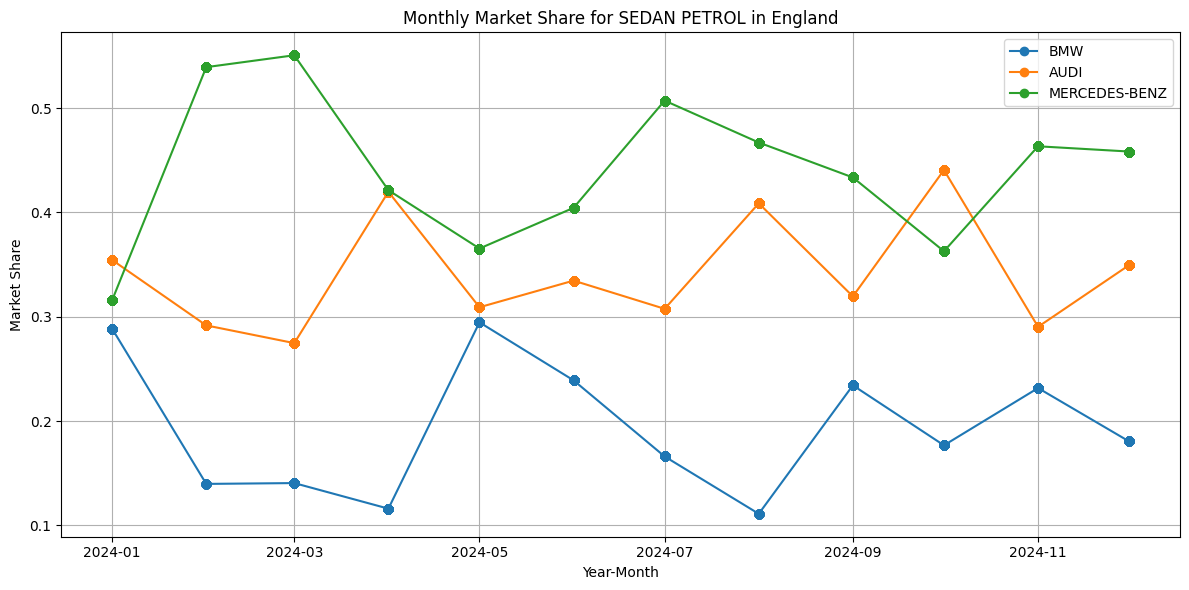

In [15]:
import matplotlib.pyplot as plt

# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England
oems = ['BMW', 'AUDI', 'MERCEDES-BENZ']
df_plot_multi = fact_market_share_country[
    (fact_market_share_country['oem'].isin(oems)) &
    (fact_market_share_country['body_type'] == 'SEDAN') &
    (fact_market_share_country['fuel_type'] == 'PETROL') &
    (fact_market_share_country['level_0_country'] == 'England')
]

# Sort by year_month
df_plot_multi = df_plot_multi.sort_values('year_month')

plt.figure(figsize=(12, 6))
for oem in oems:
    df_oem = df_plot_multi[df_plot_multi['oem'] == oem]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem)

plt.title('Monthly Market Share for SEDAN PETROL in England')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
fact_market_share_district.columns

Index(['total_vehicle_count_id', 'market_share_id', 'oem', 'year_report',
       'month_report', 'level_0_country', 'level_1_region_name',
       'level_2_district_postcode', 'level_2_district_town_name', 'body_type',
       'fuel_type', 'total_vehicles_district', 'total_vehicles_district_oem',
       'year_month', 'market_share_district'],
      dtype='object')

# Star Schema Creation

This section transforms the preprocessed market share data into a dimensional star schema structure for optimized analytical querying. The ETL process creates:

## Dimension Tables
- **DimTime**: Time-based attributes with quarterly aggregations
- **DimOEM**: Original Equipment Manufacturer details with categorization
- **DimVehicle**: Vehicle type combinations (body type + fuel type)
- **DimGeographyCountry**: Country-level geographic dimensions
- **DimGeographyDistrict**: Detailed district-level geographic dimensions

## Fact Tables
- **FactMarketShareCountry**: Aggregated market share metrics at country level
- **FactMarketShareDistrict**: Detailed market share metrics at district level

The star schema design enables efficient joins and analytical queries while maintaining data integrity through surrogate keys. This structure supports complex business intelligence queries and provides better performance compared to the original normalized fact tables.

In [ ]:
# Run the star schema ETL process
import sys
import os

# Add the project root to the path
project_root = os.path.dirname(os.getcwd())
sys.path.append(project_root)

# Import and run the ETL
from scripts.create_star_schema import VehicleMarketStarSchemaETL

# Initialize ETL processor
data_dir = "../data"
output_dir = "../data/star_schema"
etl = VehicleMarketStarSchemaETL(data_dir=data_dir, output_dir=output_dir)

# Run the ETL process
print("Running Star Schema ETL...")
etl.run_etl()

In [18]:
# Examine the created star schema tables
import pandas as pd
import os

star_schema_dir = "../data/star_schema"

# Load and examine dimension tables
print("=== DIMENSION TABLES ===\n")

# DimTime
dim_time = pd.read_parquet(os.path.join(star_schema_dir, "DimTime.parquet"))
print("DimTime (first 5 rows):")
print(dim_time.head())
print(f"Shape: {dim_time.shape}\n")

# DimOEM
dim_oem = pd.read_parquet(os.path.join(star_schema_dir, "DimOEM.parquet"))
print("DimOEM (first 10 rows):")
print(dim_oem.head(10))
print(f"Shape: {dim_oem.shape}\n")

# DimVehicle
dim_vehicle = pd.read_parquet(os.path.join(star_schema_dir, "DimVehicle.parquet"))
print("DimVehicle:")
print(dim_vehicle)
print(f"Shape: {dim_vehicle.shape}\n")

# DimGeographyCountry
dim_geo_country = pd.read_parquet(os.path.join(star_schema_dir, "DimGeographyCountry.parquet"))
print("DimGeographyCountry:")
print(dim_geo_country)
print(f"Shape: {dim_geo_country.shape}\n")

# DimGeographyDistrict (sample)
dim_geo_district = pd.read_parquet(os.path.join(star_schema_dir, "DimGeographyDistrict.parquet"))
print("DimGeographyDistrict (first 10 rows):")
print(dim_geo_district.head(10))
print(f"Shape: {dim_geo_district.shape}\n")

=== DIMENSION TABLES ===

DimTime (first 5 rows):
   time_key  year_report  month_report year_month  quarter year_quarter
0    202404         2024             4 2024-04-01        2      2024-Q2
1    202401         2024             1 2024-01-01        1      2024-Q1
2    202403         2024             3 2024-03-01        1      2024-Q1
3    202409         2024             9 2024-09-01        3      2024-Q3
4    202411         2024            11 2024-11-01        4      2024-Q4
Shape: (12, 6)

DimOEM (first 10 rows):
   oem_key       oem_name oem_category country_origin
0        1   ASTON MARTIN       Luxury             UK
1        2           AUDI       Luxury        Germany
2        3        BENTLEY       Luxury             UK
3        4            BMW       Luxury        Germany
4        5        FERRARI       Luxury          Italy
5        6         JAGUAR       Luxury             UK
6        7          LEXUS      Premium          Japan
7        8       MASERATI       Luxury        

In [20]:
# Examine fact tables and perform sample analytical queries
print("=== FACT TABLES ===\n")

# Load fact tables
fact_country = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareCountry.parquet"))
fact_district = pd.read_parquet(os.path.join(star_schema_dir, "FactMarketShareDistrict.parquet"))

print("FactMarketShareCountry (sample):")
print(fact_country.head())
print(f"Shape: {fact_country.shape}\n")

print("FactMarketShareDistrict (sample):")
print(fact_district.head())
print(f"Shape: {fact_district.shape}\n")

print("=== SAMPLE ANALYTICAL QUERIES ===\n")

# Query 1: Top 5 OEMs by total vehicles in country-level data
print("1. Top 5 OEMs by Total Vehicles (Country Level):")
oem_performance = fact_country.groupby('oem_key').agg({
    'total_vehicles_country_oem': 'sum',
    'market_share_country': 'mean'
}).reset_index()

# Join with OEM dimension for names
oem_performance = oem_performance.merge(dim_oem[['oem_key', 'oem_name', 'oem_category']], on='oem_key')
oem_performance = oem_performance.sort_values('total_vehicles_country_oem', ascending=False).head()

for _, row in oem_performance.iterrows():
    print(f"  {row['oem_name']} ({row['oem_category']}): {row['total_vehicles_country_oem']:,} vehicles, "
          f"{row['market_share_country']:.4f} avg market share")

print()

# Query 2: Vehicle type performance
print("2. Vehicle Type Performance:")
vehicle_performance = fact_country.groupby('vehicle_key').agg({
    'total_vehicles_country_oem': 'sum',
    'market_share_country': 'mean'
}).reset_index()

vehicle_performance = vehicle_performance.merge(dim_vehicle, on='vehicle_key')
vehicle_performance = vehicle_performance.sort_values('total_vehicles_country_oem', ascending=False)

for _, row in vehicle_performance.iterrows():
    print(f"  {row['vehicle_desc']}: {row['total_vehicles_country_oem']:,} vehicles, "
          f"{row['market_share_country']:.4f} avg market share")

print()

# Query 3: Geographic performance (country level)
print("3. Geographic Performance by Country:")
geo_performance = fact_country.groupby('geography_country_key').agg({
    'total_vehicles_country': 'mean',
    'market_share_country': 'mean'
}).reset_index()

geo_performance = geo_performance.merge(dim_geo_country, on='geography_country_key')
geo_performance = geo_performance.sort_values('total_vehicles_country', ascending=False)

for _, row in geo_performance.iterrows():
    print(f"  {row['country_name']} ({row['country_code']}): {row['total_vehicles_country']:,.0f} avg total vehicles")

print()

# Query 4: Time trend analysis (monthly aggregation)
print("4. Monthly Market Trends (Total Vehicles by Month):")
time_trends = fact_country.groupby('time_key').agg({
    'total_vehicles_country': 'mean'
}).reset_index()

time_trends = time_trends.merge(dim_time[['time_key', 'year_report', 'month_report']], on='time_key')
time_trends = time_trends.sort_values('time_key').head(10)

for _, row in time_trends.iterrows():
    year = int(row['year_report'])
    month = int(row['month_report'])
    vehicles = int(row['total_vehicles_country'])
    print(f"  {year}-{month:02d}: {vehicles:,} avg vehicles")

=== FACT TABLES ===

FactMarketShareCountry (sample):
   fact_country_key  time_key  oem_key  vehicle_key  geography_country_key  \
0                 1    202404        1            1                    5.0   
1                 2    202401        1            1                    1.0   
2                 3    202403        1            1                    1.0   
3                 4    202404        1            1                    1.0   
4                 5    202404        1            1                    1.0   

   total_vehicles_country  total_vehicles_country_oem  market_share_country  
0                    13.0                         1.0              0.076923  
1                   527.0                        66.0              0.125237  
2                   885.0                        79.0              0.089266  
3                   426.0                        27.0              0.063380  
4                   426.0                        27.0              0.063380  
Shape: (3

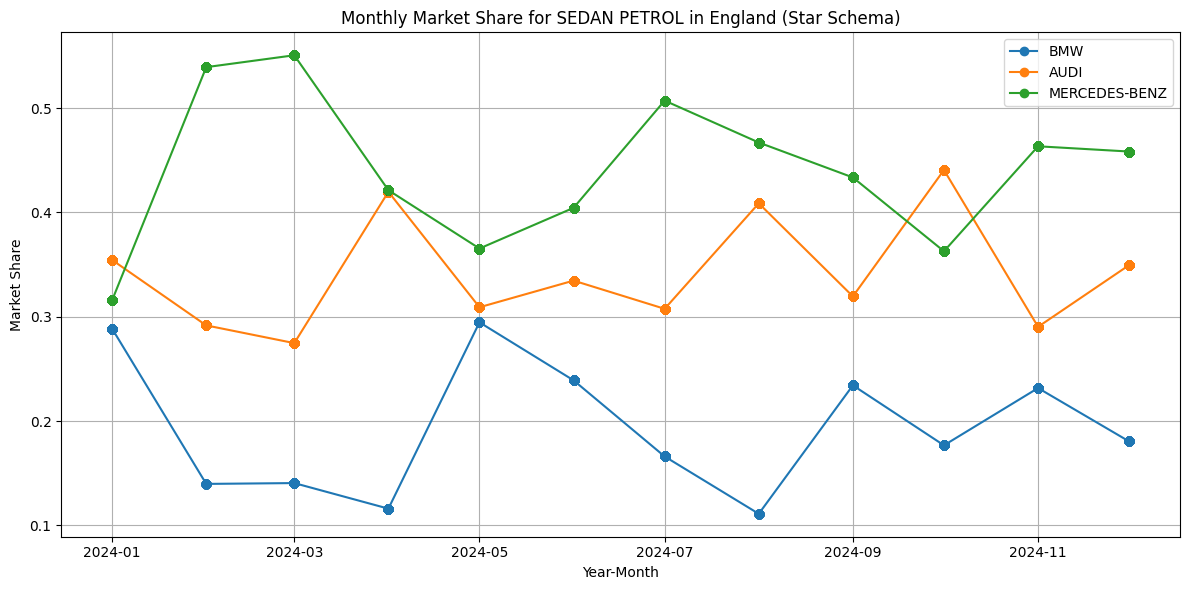

Total rows in star schema plot: 19049
Unique OEMs: ['BMW' 'AUDI' 'MERCEDES-BENZ']


In [21]:
# Replicate the analysis using the star schema with proper joins
# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England using dimension joins

# Get the keys for filtering
oem_keys = dim_oem[dim_oem['oem_name'].isin(['BMW', 'AUDI', 'MERCEDES-BENZ'])]['oem_key'].tolist()
vehicle_key = dim_vehicle[(dim_vehicle['body_type'] == 'SEDAN') & (dim_vehicle['fuel_type'] == 'PETROL')]['vehicle_key'].iloc[0]
geography_key = dim_geo_country[dim_geo_country['country_name'] == 'England']['geography_country_key'].iloc[0]

# Filter the fact table using the keys
df_plot_star = fact_country[
    (fact_country['oem_key'].isin(oem_keys)) &
    (fact_country['vehicle_key'] == vehicle_key) &
    (fact_country['geography_country_key'] == geography_key)
]

# Join with dimension tables to get descriptive names
df_plot_star = df_plot_star.merge(dim_oem[['oem_key', 'oem_name']], on='oem_key')
df_plot_star = df_plot_star.merge(dim_time[['time_key', 'year_month']], on='time_key')

# Sort by year_month
df_plot_star = df_plot_star.sort_values('year_month')

# Create the plot
plt.figure(figsize=(12, 6))
for oem_name in ['BMW', 'AUDI', 'MERCEDES-BENZ']:
    df_oem = df_plot_star[df_plot_star['oem_name'] == oem_name]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem_name)

plt.title('Monthly Market Share for SEDAN PETROL in England (Star Schema)')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total rows in star schema plot: {len(df_plot_star)}")
print(f"Unique OEMs: {df_plot_star['oem_name'].unique()}")

In [26]:
import numpy as np

# Convert both series to numpy arrays and round to 3 decimal places
star_values = np.round(df_plot_star['market_share_country'].values, 3)
multi_values = np.round(df_plot_multi['market_share_country'].values, 3)

# Check if arrays have the same length
print(f"Star schema length: {len(star_values)}")
print(f"Multi table length: {len(multi_values)}")

# Check if all values are equal with 3 decimal precision
arrays_equal = np.array_equal(star_values, multi_values)
print(f"Arrays are equal (3 decimal precision): {arrays_equal}")

# If not equal, show differences
if not arrays_equal:
    # Find positions where values differ
    diff_mask = star_values != multi_values
    if np.any(diff_mask):
        print(f"Number of differing positions: {np.sum(diff_mask)}")
        print("First 5 differences:")
        diff_indices = np.where(diff_mask)[0][:5]
        for idx in diff_indices:
            print(f"Position {idx}: Star={star_values[idx]}, Multi={multi_values[idx]}")

Star schema length: 19049
Multi table length: 19049
Arrays are equal (3 decimal precision): True


# SQLite Database

In [27]:
import sqlite3

# Connect to the SQLite database
conn = sqlite3.connect("../data/market_share.sqlite")

# Get a cursor object
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(f"  - {table[0]}")

# Close the connection
conn.close()

Tables in the database:
  - DimTime
  - DimOEM
  - DimVehicle
  - DimGeographyCountry
  - DimGeographyDistrict
  - FactMarketShareCountry
  - FactMarketShareDistrict


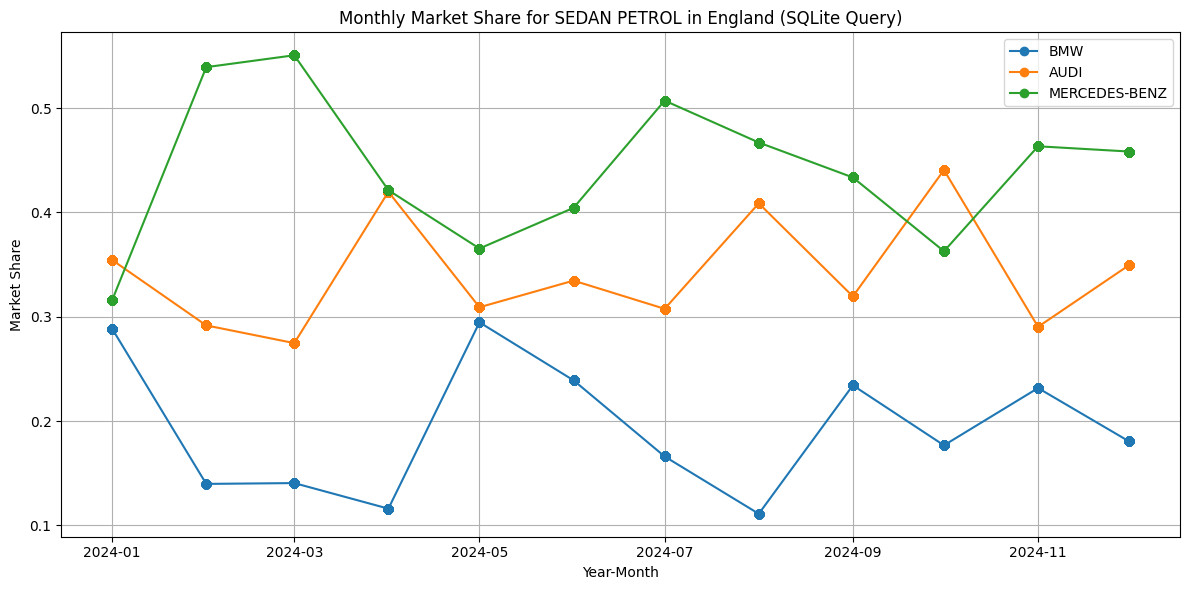

Total rows from SQLite query: 19049
Unique OEMs: ['AUDI' 'BMW' 'MERCEDES-BENZ']
Data shape: (19049, 3)


In [28]:
# Replicate the analysis using SQLite database with SQL queries
# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England using SQL joins

# Connect to the SQLite database
conn = sqlite3.connect("../data/market_share.sqlite")

# SQL query to get the same data using joins
sql_query = """
SELECT 
    f.market_share_country,
    o.oem_name,
    t.year_month
FROM FactMarketShareCountry f
JOIN DimOEM o ON f.oem_key = o.oem_key
JOIN DimVehicle v ON f.vehicle_key = v.vehicle_key
JOIN DimGeographyCountry g ON f.geography_country_key = g.geography_country_key
JOIN DimTime t ON f.time_key = t.time_key
WHERE 
    o.oem_name IN ('BMW', 'AUDI', 'MERCEDES-BENZ')
    AND v.body_type = 'SEDAN'
    AND v.fuel_type = 'PETROL'
    AND g.country_name = 'England'
ORDER BY t.year_month, o.oem_name
"""

# Execute query and get results
df_plot_sql = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Convert year_month to datetime for plotting
df_plot_sql['year_month'] = pd.to_datetime(df_plot_sql['year_month'])

# Create the plot
plt.figure(figsize=(12, 6))
for oem_name in ['BMW', 'AUDI', 'MERCEDES-BENZ']:
    df_oem = df_plot_sql[df_plot_sql['oem_name'] == oem_name]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem_name)

plt.title('Monthly Market Share for SEDAN PETROL in England (SQLite Query)')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total rows from SQLite query: {len(df_plot_sql)}")
print(f"Unique OEMs: {df_plot_sql['oem_name'].unique()}")
print(f"Data shape: {df_plot_sql.shape}")